In [1]:
!pip install datasets nltk rouge-score tqdm

In [2]:
!pip install matplotlib

In [3]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

import nltk
import numpy as np
from collections import Counter
from tqdm import tqdm

In [5]:
import nltk 
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
!nvidia-smi

Sat Apr 11 14:52:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())


True
2


In [9]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cu128
12.8


In [10]:
from datasets import load_dataset


In [11]:
dataset=load_dataset("Sandesh-Lav/potato-tuber-caption-dataset")

train_data = dataset["train"]
val_data = dataset["validation"]
test_data = dataset["test"]


from datasets import Image
dataset = dataset.with_format("python")

README.md:   0%|          | 0.00/596 [00:00<?, ?B/s]

data/train-00000-of-00011.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

data/train-00001-of-00011.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00011.parquet:   0%|          | 0.00/488M [00:00<?, ?B/s]

data/train-00003-of-00011.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

...

data/validation-00000-of-00001.parquet:   0%|          | 0.00/284M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/298M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8307 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/461 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/462 [00:00<?, ? examples/s]

In [12]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 8307
    })
    validation: Dataset({
        features: ['image', 'caption'],
        num_rows: 461
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 462
    })
})

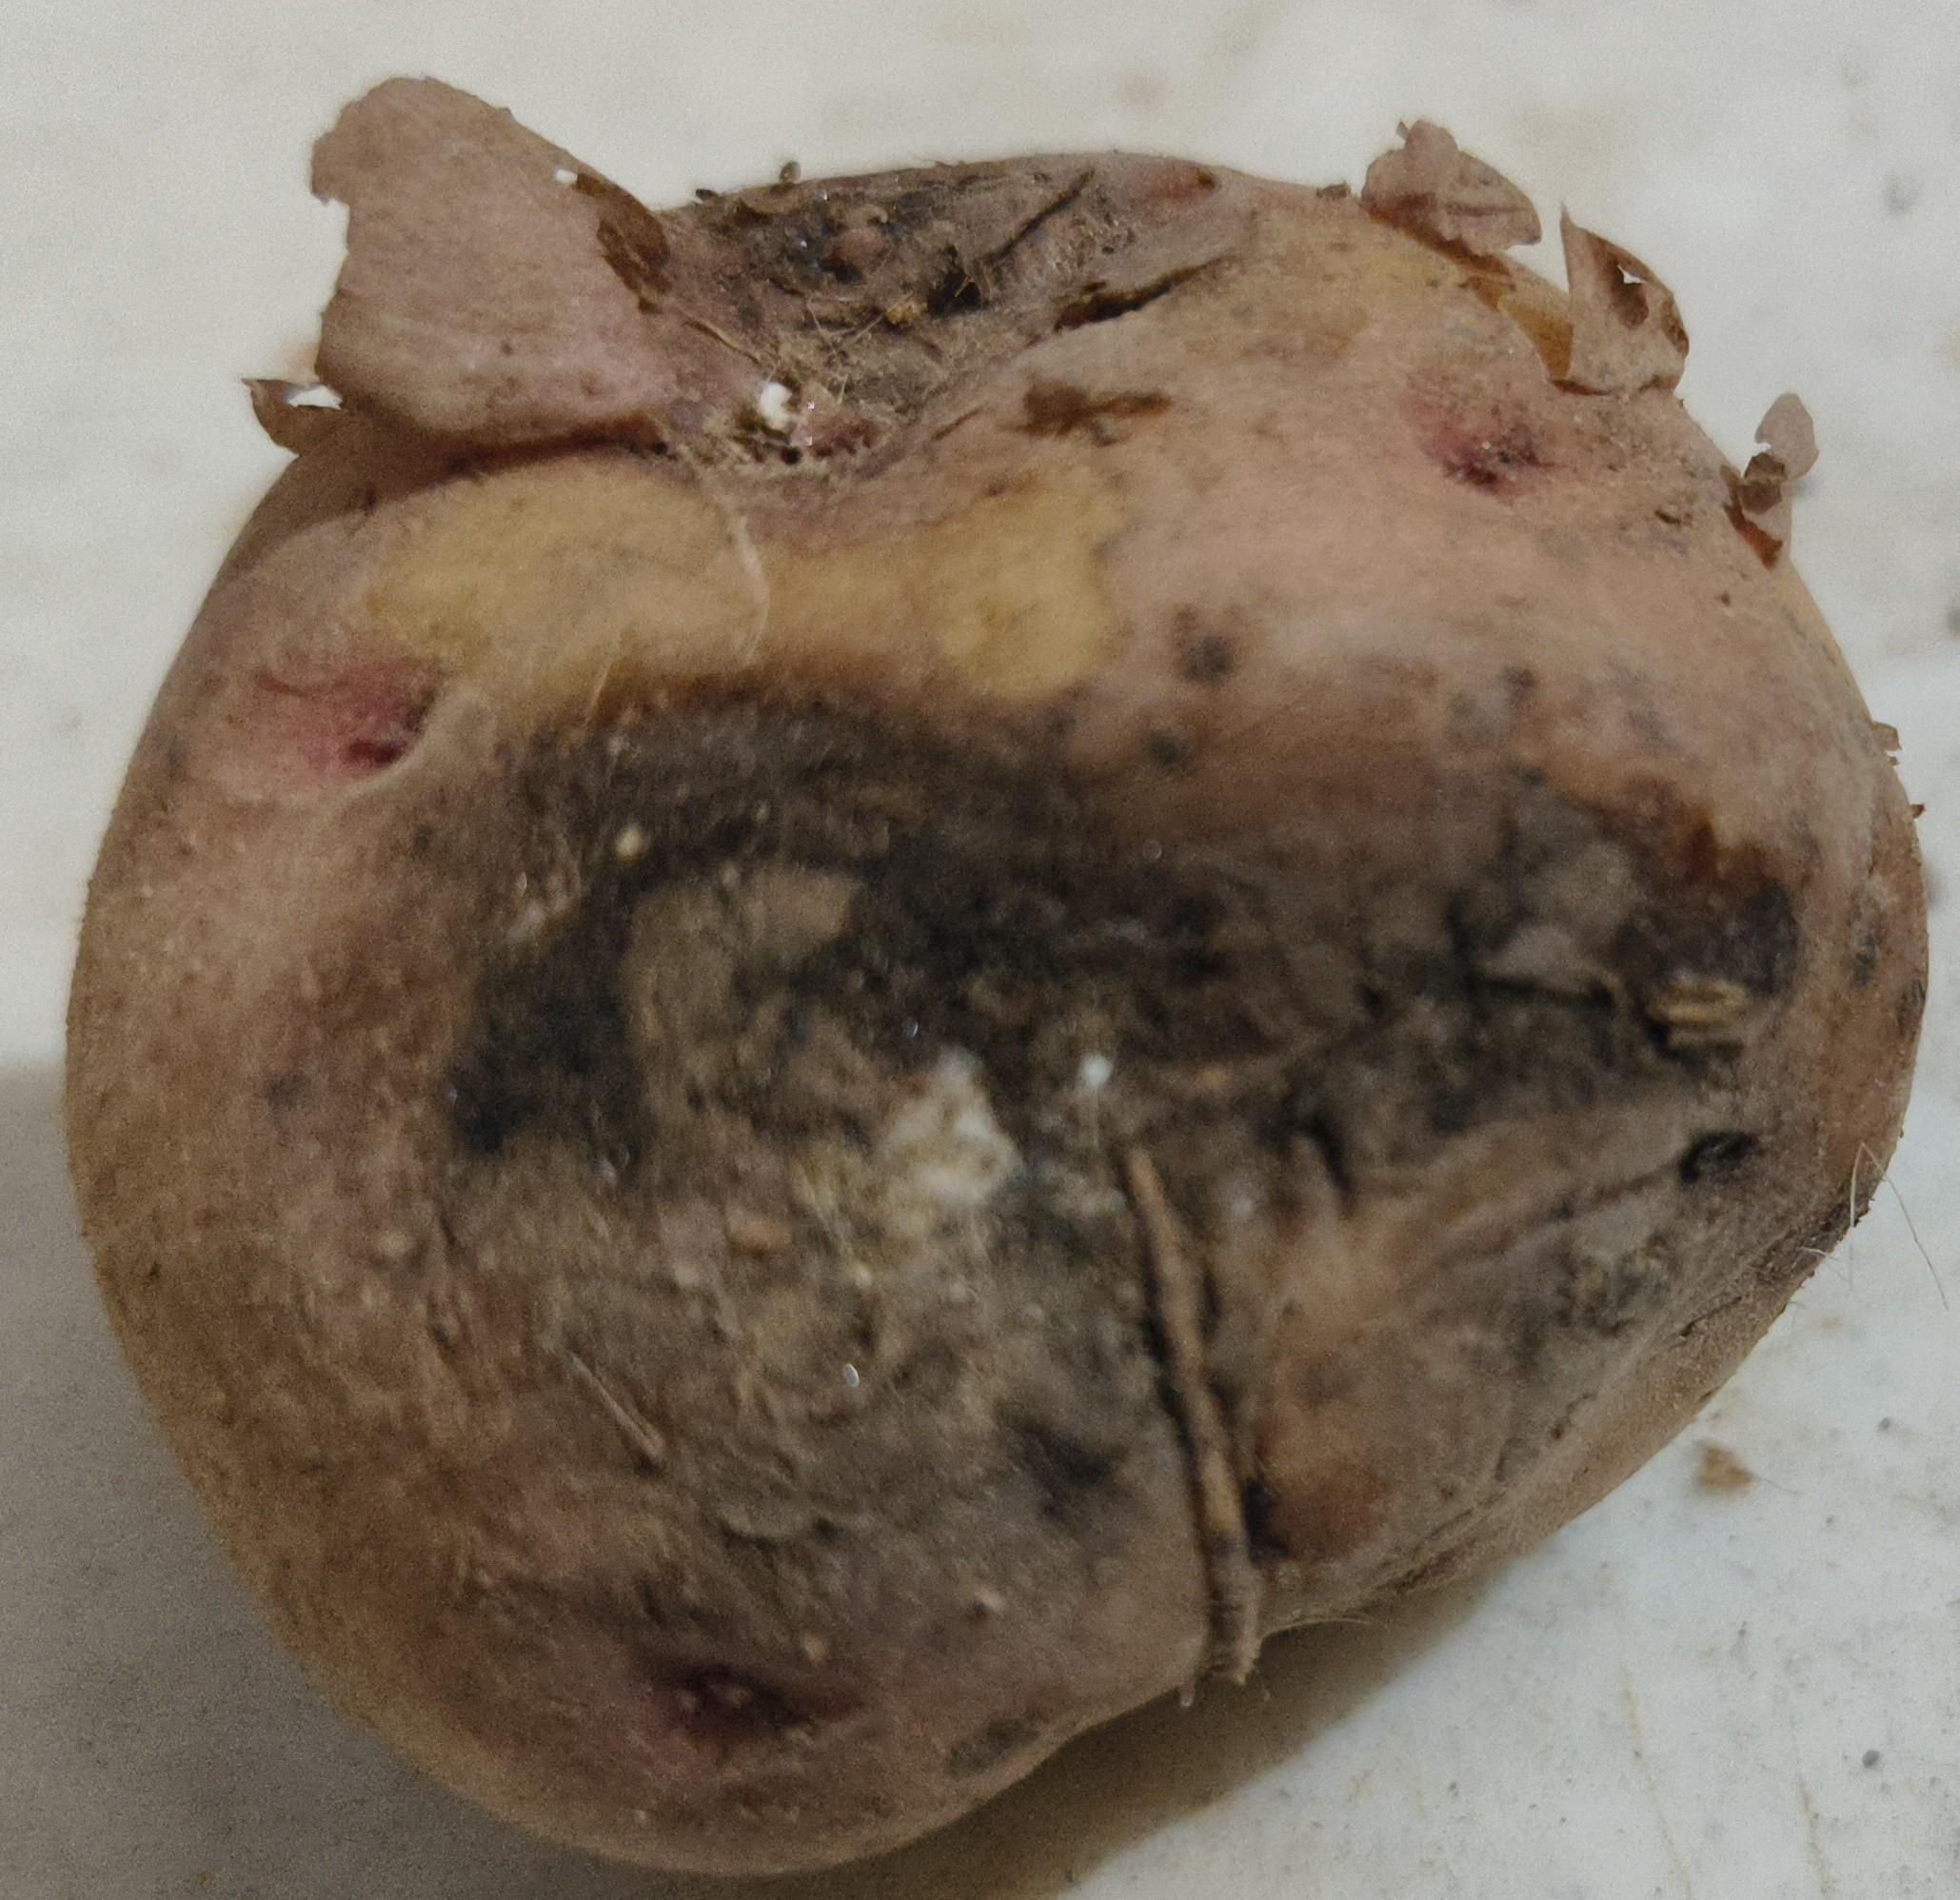

In [15]:
import io
from PIL import Image

img_bytes = train_data[0]['image']['bytes']

img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

img

In [16]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [17]:
captions = []

for item in train_data:
    tokens = word_tokenize(item["caption"].lower())
    tokens = ["<start>"] + tokens + ["<end>"]
    captions.append(tokens)

words = []

for cap in captions:
    words.extend(cap)

vocab = Counter(words)

word2idx = {w: i+1 for i,(w,_) in enumerate(vocab.items())}
word2idx["<pad>"] = 0
word2idx["<unk>"] = len(word2idx)

idx2word = {i:w for w,i in word2idx.items()}

vocab_size = len(word2idx)

In [18]:
def encode_caption(caption):

    tokens = word_tokenize(caption.lower())
    tokens = ["<start>"] + tokens + ["<end>"]

    return [word2idx.get(w, word2idx["<unk>"]) for w in tokens]

In [19]:
print(word2idx["<start>"])
print(vocab)

1
Counter({'<start>': 8307, '<end>': 8307, '.': 8299, 'a': 8046, 'tuber': 7784, 'potato': 7069, 'rot': 3809, 'moderate': 3583, 'the': 3577, 'whole': 3568, 'of': 3327, 'with': 2906, 'tissue': 2707, 'dry': 2592, ',': 2024, 'internal': 2010, 'soft': 1991, 'by': 1826, 'mild': 1768, 'and': 1681, 'surface': 1630, 'exhibiting': 1585, 'severe': 1571, 'showing': 1533, 'sample': 1510, 'on': 1411, 'displaying': 1357, 'lesions': 1354, 'affected': 1240, 'outer': 1084, 'characteristic': 983, 'associated': 874, 'disease': 857, 'scab': 765, 'cut': 756, 'to': 683, 'cut-section': 682, 'within': 682, 'an': 673, 'symptoms': 669, 'due': 645, 'greening': 616, 'cross-section': 614, 'cut-open': 584, 'decay': 579, 'sliced': 577, 'infection': 567, 'peel': 555, 'sunken': 501, 'in': 493, 'fungal': 488, 'colonization': 488, 'healthy': 481, 'caused': 479, 'longitudinal': 479, 'view': 479, 'common': 469, 'corky': 466, 'late': 465, 'blight': 465, 'softening': 436, 'covering': 406, 'discoloration': 391, 'water-soaked'

In [23]:
from PIL import Image
import io
import torch
from torch.utils.data import Dataset

class CaptionDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        item = self.data[idx]

        img_bytes = item["image"]["bytes"]
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        img = transform(img)

        cap = encode_caption(item["caption"])

        return img, torch.tensor(cap)

In [24]:
def collate_fn(batch):

    imgs, caps = zip(*batch)

    imgs = torch.stack(imgs)

    caps = nn.utils.rnn.pad_sequence(
        caps,
        batch_first=True,
        padding_value=0
    )

    return imgs, caps

In [32]:
from torch.utils.data import Dataset, DataLoader

train_loader = DataLoader(
    CaptionDataset(train_data),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    CaptionDataset(val_data),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    CaptionDataset(test_data),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [33]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

modules = list(resnet.children())[:-1]

cnn = nn.Sequential(*modules)

for p in cnn.parameters():
    p.requires_grad = False

cnn = cnn.to(device)
cnn.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s] 


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [34]:
class CaptionModel(nn.Module):

    def __init__(self,vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size,256)

        self.img_fc = nn.Linear(2048,512)

        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=512,
            batch_first=True
        )

        self.fc = nn.Linear(512,vocab_size)

    def forward(self,features,captions):

        emb = self.embedding(captions)

        h0 = self.img_fc(features).unsqueeze(0)
        c0 = torch.zeros_like(h0)

        outputs,_ = self.lstm(emb,(h0,c0))

        outputs = self.fc(outputs)

        return outputs

In [35]:
model = CaptionModel(vocab_size).to(device)

In [36]:
def extract_features(images):

    with torch.no_grad():
        features = cnn(images)

    features = features.view(features.size(0),-1)

    return features

In [37]:
criterion = nn.CrossEntropyLoss(ignore_index=0)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

In [38]:
def validate():

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for imgs,caps in val_loader:

            imgs = imgs.to(device)
            caps = caps.to(device)

            feats = extract_features(imgs)

            out = model(feats,caps[:,:-1])

            loss = criterion(
                out.reshape(-1,vocab_size),
                caps[:,1:].reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(val_loader)

In [39]:
epochs = 10

best_val = float("inf")

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for imgs,caps in tqdm(train_loader):

        imgs = imgs.to(device)
        caps = caps.to(device)

        feats = extract_features(imgs)

        optimizer.zero_grad()

        out = model(feats,caps[:,:-1])

        loss = criterion(
            out.reshape(-1,vocab_size),
            caps[:,1:].reshape(-1)
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    val_loss = validate()

    print(
        f"Epoch {epoch+1} | Train {train_loss/len(train_loader):.4f} | Val {val_loss:.4f}"
    )

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(),"best_model.pth")

100%|██████████| 260/260 [04:50<00:00,  1.12s/it]


Epoch 1 | Train 0.6712 | Val 0.2424


100%|██████████| 260/260 [04:51<00:00,  1.12s/it]


Epoch 2 | Train 0.2366 | Val 0.2217


100%|██████████| 260/260 [04:50<00:00,  1.12s/it]


...

Epoch 8 | Train 0.1736 | Val 0.1707


100%|██████████| 260/260 [04:52<00:00,  1.13s/it]


Epoch 9 | Train 0.1713 | Val 0.1701


100%|██████████| 260/260 [04:53<00:00,  1.13s/it]


Epoch 10 | Train 0.1676 | Val 0.1642


In [40]:
def generate_caption_from_feature(feature, max_len=20):

    model.eval()

    caption = ["<start>"]

    for _ in range(max_len):

        seq = torch.tensor(
            [word2idx[w] for w in caption]
        ).unsqueeze(0).to(device)

        out = model(feature, seq)

        idx = out[:, -1, :].argmax().item()

        word = idx2word[idx]

        caption.append(word)

        if word == "<end>":
            break

    return caption[1:-1]

In [41]:
!pip install pycocoevalcap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 18.3 MB/s eta 0:00:0000:0100:01


In [42]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
def evaluate():

    model.eval()

    bleu1, bleu2, bleu3, bleu4, bleu5 = [], [], [], [], []
    meteor = []
    rouge = []

    scorer = rouge_scorer.RougeScorer(["rougeL"])
    cider_scorer = Cider()

    gts = {}
    res = {}

    img_id = 0

    with torch.no_grad():

        for imgs, caps in tqdm(test_loader):

            imgs = imgs.to(device)
            caps = caps.to(device)

            feats = extract_features(imgs)

            for i in range(len(imgs)):

                feature = feats[i].unsqueeze(0)

                pred = generate_caption_from_feature(feature)
                pred_sentence = " ".join(pred)

                # reference caption
                ref_tokens = [
                    idx2word[idx.item()]
                    for idx in caps[i]
                    if idx.item() != 0
                ]

                ref_sentence = " ".join(ref_tokens[1:-1])

                smooth = SmoothingFunction().method1

                # BLEU
                bleu1.append(sentence_bleu([ref_sentence.split()], pred,
                          weights=(1, 0, 0, 0, 0),
                          smoothing_function=smooth))

                bleu2.append(sentence_bleu([ref_sentence.split()], pred,
                          weights=(0.5, 0.5, 0, 0, 0),
                          smoothing_function=smooth))

                bleu3.append(sentence_bleu([ref_sentence.split()], pred,
                          weights=(0.33, 0.33, 0.33, 0, 0),
                          smoothing_function=smooth))

                bleu4.append(sentence_bleu([ref_sentence.split()], pred,
                          weights=(0.25, 0.25, 0.25, 0.25, 0),
                          smoothing_function=smooth))

                bleu5.append(sentence_bleu([ref_sentence.split()], pred,
                          weights=(0.2, 0.2, 0.2, 0.2, 0.2),
                          smoothing_function=smooth))

                # METEOR
                meteor.append(
                    meteor_score(
                        [ref_sentence.split()],
                        pred_sentence.split()
                    )
                )

                # ROUGE
                rouge.append(
                    scorer.score(ref_sentence, pred_sentence)["rougeL"].fmeasure
                )

                # CIDEr format
                gts[img_id] = [ref_sentence]
                res[img_id] = [pred_sentence]

                img_id += 1

    cider_score, _ = cider_scorer.compute_score(gts, res)

    print("BLEU-1:", np.mean(bleu1))
    print("BLEU-2:", np.mean(bleu2))
    print("BLEU-3:", np.mean(bleu3))
    print("BLEU-4:", np.mean(bleu4))
    print("BLEU-5:", np.mean(bleu5))
    print("METEOR:", np.mean(meteor))
    print("ROUGE:", np.mean(rouge))
    print("CIDEr:", cider_score)

In [43]:
evaluate()

100%|██████████| 15/15 [00:24<00:00,  1.65s/it]

BLEU-1: 0.46829830139990913
BLEU-2: 0.3438840904544821
BLEU-3: 0.26765888191735343
BLEU-4: 0.22557631306933207
BLEU-5: 0.18839642407384852
METEOR: 0.4647116508281236
ROUGE: 0.4463594690388623
CIDEr: 1.6396680983913485
